## ***Initials***

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
from io import StringIO
from folium.plugins import MarkerCluster

## ***Help Functions***

In [81]:
# function that: plots the means of the economic hierarchy groups, showcasing the hierarchical structure
def plot_economic_hierarchy_means(df, color_palette=None):

    # Define the features and hierarchy groups
    groups = {
        'Οικονομικά ενεργοί': ['Απασχολούμενοι', 'Άνεργοι'],
        'Απασχολούμενοι': ['Πρωτογενής', 'Δευτερογενής', 'Τριτογενής']
    }

    # Compute means
    mean_values = {
        'Οικονομικά ενεργοί': df['Οικονομικά ενεργοί'].mean(),
        'Οικονομικά μη ενεργοί': df['Οικονομικά μη ενεργοί'].mean(),
        'Απασχολούμενοι': df['Απασχολούμενοι'].mean(),
        'Άνεργοι': df['Άνεργοι'].mean(),
        'Πρωτογενής': df['Πρωτογενής'].mean(),
        'Δευτερογενής': df['Δευτερογενής'].mean(),
        'Τριτογενής': df['Τριτογενής'].mean()
    }

    if color_palette is None:
        color_palette = {
            'Οικονομικά μη ενεργοί': '#cccccc',
            'Οικονομικά ενεργοί': '#87ceeb',
            'Απασχολούμενοι': '#4682b4',
            'Άνεργοι': '#ff7f50',
            'Πρωτογενής': '#9acd32',
            'Δευτερογενής': '#daa520',
            'Τριτογενής': '#9370db'
        }

    # Create hierarchical structure manually
    fig, ax = plt.subplots(figsize=(10, 6))

    # Stack bar: Inactive vs Active
    ax.bar('Population', mean_values['Οικονομικά ενεργοί'], label='Οικονομικά ενεργοί', 
           color=color_palette['Οικονομικά ενεργοί'])

    active_bottom = mean_values['Οικονομικά ενεργοί']
    ax.bar('Population', mean_values['Οικονομικά μη ενεργοί'], bottom=active_bottom,
           label='Οικονομικά μη ενεργοί', color=color_palette['Οικονομικά μη ενεργοί'])

    # Stack bar: Within Active → Employed vs Unemployed
    employed_bottom = active_bottom
    ax.bar('Απασχόληση', mean_values['Απασχολούμενοι'], label='Απασχολούμενοι',
           color=color_palette['Απασχολούμενοι'])
    ax.bar('Απασχόληση', mean_values['Άνεργοι'], bottom=mean_values['Απασχολούμενοι'],
           label='Άνεργοι', color=color_palette['Άνεργοι'])

    # Stack bar: Within Employed → Sectors
    ax.bar('Τομείς', mean_values['Πρωτογενής'], label='Πρωτογενής', 
           color=color_palette['Πρωτογενής'])
    ax.bar('Τομείς', mean_values['Δευτερογενής'], bottom=mean_values['Πρωτογενής'], 
           label='Δευτερογενής', color=color_palette['Δευτερογενής'])
    sector_bottom = mean_values['Πρωτογενής'] + mean_values['Δευτερογενής']
    ax.bar('Τομείς', mean_values['Τριτογενής'], bottom=sector_bottom, 
           label='Τριτογενής', color=color_palette['Τριτογενής'])

    ax.set_title("Hierarchical Employment Structure (Mean Values)")
    ax.set_ylabel("Average Number of People")
    ax.grid(axis='y')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [77]:
# function that: checks the consistency of the hierarchical economic data
def check_hierarchical_data_consistency(df):

    # Compute differences per row
    df_errors = pd.DataFrame(index=df.index)

    df_errors["sector_error"] = (
        (df["Πρωτογενής"] + df["Δευτερογενής"] + df["Τριτογενής"]) - df["Απασχολούμενοι"]
    ).abs()

    df_errors["active_error"] = (
        (df["Απασχολούμενοι"] + df["Άνεργοι"]) - df["Οικονομικά ενεργοί"]
    ).abs()

    df_errors["total_people"] = (
        (df["Οικονομικά ενεργοί"] + df["Οικονομικά μη ενεργοί"])
    )  # no ΣΥΝΟΛΟ given — report sum

    print("Maximum errors per category:")
    print(f"  Sector sum vs Employed:         {df_errors['sector_error'].max():.2f}")
    print(f"  Employed + Unemployed vs Active:{df_errors['active_error'].max():.2f}")

    print("\nRows with inconsistencies (errors > 5 people):")

    return df_errors

In [40]:
# function that: plots the means of the age groups sorted
def plot_group_means(df, columns, color='skyblue'):

    age_means = df[columns].mean()

    # Ensure the order of columns is used
    age_means = age_means[columns]

    # Print values
    print("Average proportion per age group:")
    print(age_means.to_string())

    # Plot
    plt.figure(figsize=(10, 5))
    age_means.plot(kind='bar', color=color, edgecolor='black')
    plt.title("Average Age Group Proportions Across Municipal Communities")
    plt.xlabel("Age Group")
    plt.ylabel("Mean Proportion")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

In [41]:
# function that: prints the top N largest values in a specified column of a DataFrame
def print_top_n_largest(df, community_col, column, n=10, ascending=False):

    if column not in df.columns or community_col not in df.columns:
        print(f"Column '{column}' or '{community_col}' not found in DataFrame.")
        return

    print(f"\nTop {n} largest values in '{column}' by Municipal Community:\n")
    top_values = df[[community_col, column]].dropna().sort_values(by=column, ascending=ascending).head(n)
    print(top_values.to_string(index=False))

In [42]:
# function that: inspects the distribution of a numerical column (e.g., ratings)
def inspect_distribution_numerical(df, column, color, bins=10, xlim=None, ylim=None):

    # Total and non-null counts
    total = df.shape[0]
    non_null = df[column].notnull().sum()
    null = total - non_null
    print(f"\nColumn: {column}")
    print(f"Total entries: {total}")
    print(f"Non-null values: {non_null}")
    print(f"Missing values: {null} ({null/total:.2%})")

    # Descriptive stats
    print(f"\n{column} statistics (non-null):")
    print(df[column].dropna().describe())

    # Plot
    plt.figure(figsize=(8, 5))
    df[column].dropna().plot.hist(bins=bins, edgecolor='black', color=color)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    if xlim:
        plt.xlim(xlim)
    if ylim:
        plt.ylim(ylim)

    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()


In [43]:
# function that: inspects the distribution of a categorical column
def inspect_distribution_categorical(df, column, color, top_n=10):
    
    # Unique values
    unique_vals = df[column].unique()
    print(f"\nColumn: {column}")
    print(f"Number of unique values: {len(unique_vals)}")
    print("Sample unique values:", unique_vals[:10])

    # Frequency distribution
    val_counts = df[column].value_counts()
    print(f"\nMost common values in '{column}':")
    print(val_counts.head(30))

    # Bar plot of top N
    top_vals = val_counts.head(top_n)
    top_vals.plot(kind='barh', figsize=(10, 6), color=color)
    plt.title(f"Top {top_n} Most Common Values in '{column}'")
    plt.xlabel("Number of Entries")
    plt.ylabel(column)
    plt.gca().invert_yaxis()
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


In [44]:
# function that: find the correlation matrix of the features specified
def EDA_correlation_matrix(df, output_file_name, high_corr_threshold, features_subset=None):

    # keep the specified features
    if features_subset is not None:
        df = df[features_subset]
    
    # Compute correlation matrix
    corr = df.corr(numeric_only=True)

    # Plot heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, cmap="coolwarm", linewidths=0.5, linecolor='white', square=True, 
                cbar_kws={"shrink": 0.75}, annot=False)
    plt.title("Correlation Matrix", fontsize=16)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Create a mask for the upper triangle
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper_corr = corr.where(mask)

    # Stack and sort
    sorted_pairs = (
        upper_corr.stack()
        .reset_index()
        .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "Correlation"})
        .sort_values(by="Correlation", ascending=False)
    )

    print(f"Total non-null correlation pairs: {len(sorted_pairs)}")

    # Print high correlation pairs
    high_corr = sorted_pairs[sorted_pairs["Correlation"].abs() >= high_corr_threshold]

    if not high_corr.empty:
        print(f"\nFound {len(high_corr)} highly correlated feature pairs (|correlation| ≥ {high_corr_threshold}):")
        print(high_corr.to_string(index=False))
    else:
        print(f"\nNo feature pairs with |correlation| ≥ {high_corr_threshold}.")

    # Save to CSV
    sorted_pairs.to_csv(
        "C:/Users/Giorgos/Desktop/HMMY/10ο Εξάμηνο/Διπλωματική/5. Exploratory Data Analysis/Outputs/" + output_file_name,
        index=False
    )

## ***Load the Data***

In [45]:
df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\3. Merging the ELSTAT Data\\Extracted CSV Files\\ELSTAT-demographic-economic.csv")

In [46]:
print(df.shape)
df.head()

(76, 40)


,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Population,0-4,5-9,10-14,15-19,25-29,...,Διαζευγμένοι,20-24,Σύνολο,Οικονομικά ενεργοί,Απασχολούμενοι,Πρωτογενής,Δευτερογενής,Τριτογενής,Άνεργοι,Οικονομικά μη ενεργοί
0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Δημοτική Κοινότητα Βόλου,85806,3204,3638,4315,5086,4174,...,4530,5412,85806,35938,30389,950,5062,24377,5551,49865
1,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Αγριάς,4926,183,247,263,277,203,...,227,233,4926,1948,1642,134,306,1201,303,2981
2,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Δρακείας,369,11,14,22,16,21,...,12,15,369,139,121,55,10,56,20,227
3,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Διμηνίου,2101,102,97,112,127,119,...,72,106,2101,909,706,82,167,456,201,1194
4,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Σέσκλου,899,36,51,72,40,47,...,21,38,899,345,302,43,109,150,45,552


## ***Demographic Features: Transform Amonunts to Percentages***

In [47]:
education_cols = [
    'higher_education', 'post_secondary_non_uni', 'high_school',
    'lower_secondary', 'primary_education', 'no_formal_education'
]

age_cols = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
            '35-39','40-44','45-49','50-54','55-59','60-64','65-69',
            '70-74','75+'
]

marital_cols = ['Άγαμοι', 'Έγγαμοι', 'Χήροι', 'Διαζευγμένοι']

### ***Age Groups***

In [48]:
# Convert age groups to percentage of total population
for col in age_cols:
    df[f'{col}_pct'] = df[col] / df['Population']

### ***Education-Level Groups***

In [49]:
# Convert education to percentage of education base (excluding not_classified)
df['education_base'] = df['Population'] - df['not_classified']
for col in education_cols:
    df[f'{col}_pct'] = df[col] / df['education_base']

### ***Marriage-Status Groups***

In [50]:
# Convert marital status to percentage of total population
for col in marital_cols:
    df[f'{col}_pct'] = df[col] / df['Population']


### ***Drop old Features***

In [51]:
cols_to_drop = [
    '0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
    '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75+',
    'higher_education', 'post_secondary_non_uni', 'high_school',
    'lower_secondary', 'primary_education', 'no_formal_education',
    'Άγαμοι', 'Έγγαμοι', 'Χήροι', 'Διαζευγμένοι',
    'not_classified',
    'education_base'
]


In [52]:
df.drop(columns=cols_to_drop, inplace=True)

## ***Correlation Matrix for Feature Groups***

First of all, since I have some ***compositional feature groups***, I will inspepct them to see if there is a case of ***multicolinearity***

#### ***Age Groups***

In [53]:
age_group_features = ['0-4_pct', '5-9_pct', '10-14_pct', '15-19_pct',
       '20-24_pct', '25-29_pct', '30-34_pct', '35-39_pct', '40-44_pct',
       '45-49_pct', '50-54_pct', '55-59_pct', '60-64_pct', '65-69_pct',
       '70-74_pct', '75+_pct'
]

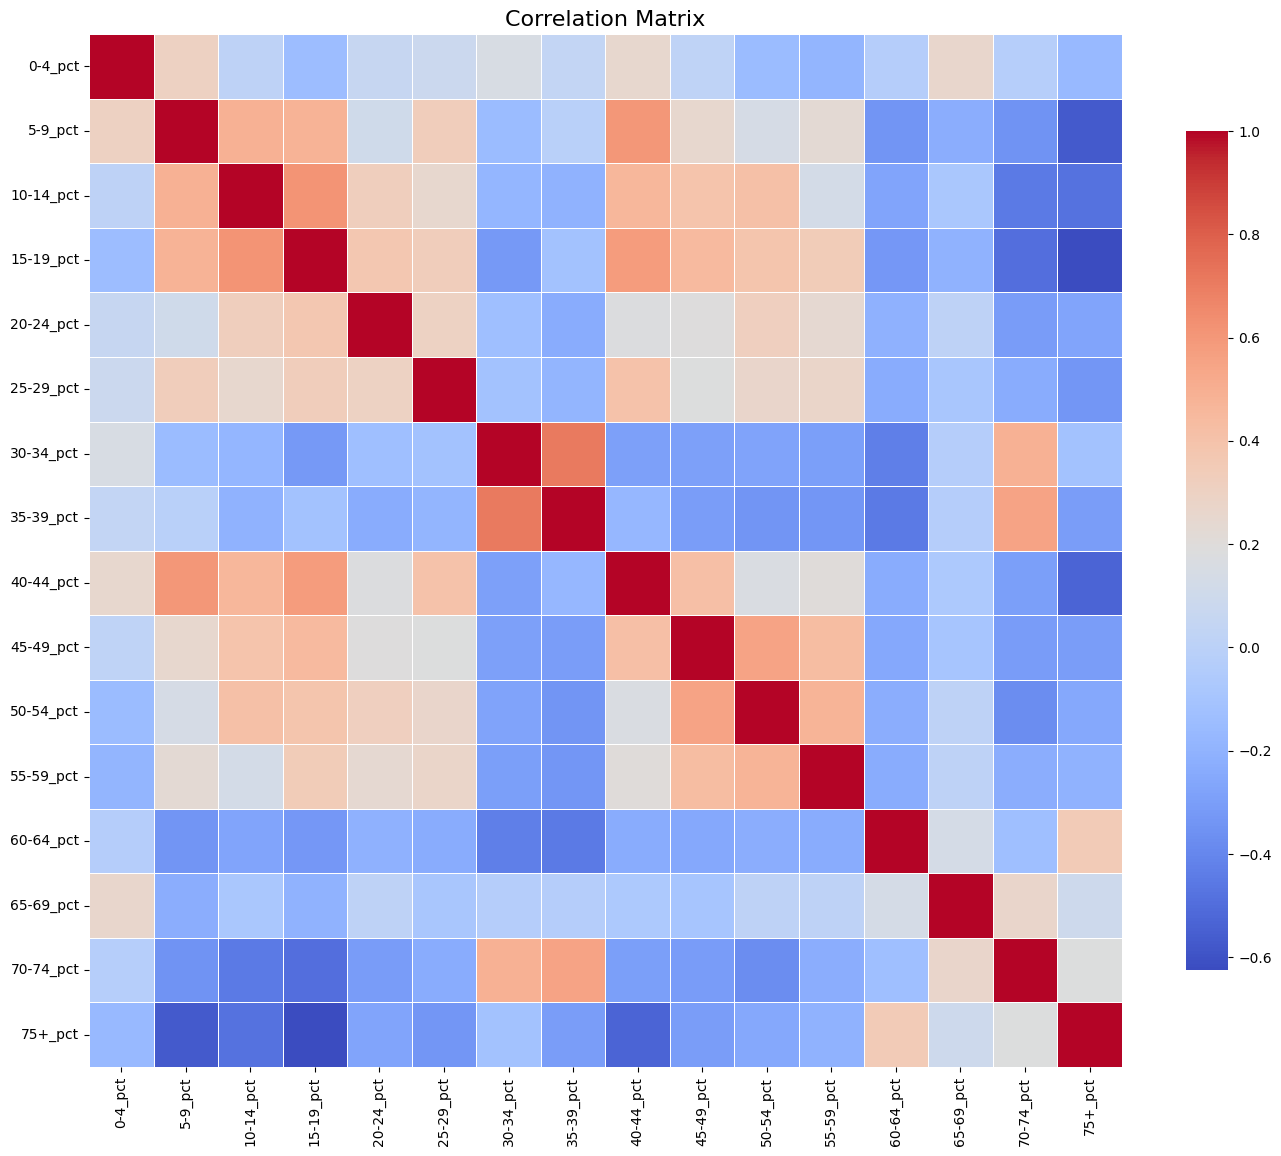

Total non-null correlation pairs: 120

Found 1 highly correlated feature pairs (|correlation| ≥ 0.7):
Feature 1 Feature 2  Correlation
30-34_pct 35-39_pct     0.711344


In [54]:
EDA_correlation_matrix(df, output_file_name="3. correlations_age_groups.csv", features_subset=age_group_features, high_corr_threshold=0.7)

The correlation matrix confirms multicollinearity among the age group features, specifically:
- **Strong positive correlations between adjacent age groups**:  70–74_pct/75+_pct: r = 0.84, 0–4_pct/5–9_pct: r = 0.81, which is expected due to natural age continuity
- **Strong negative correlations between distant age groups**: 25–29_pct/65–69_pct: r = –0.75, 35–39_pct/75+_pct: r = –0.77, which is expected due to the composational age group  that they belong to

#### ***Education-Level Groups***

In [55]:
education_level_group_features = ['higher_education_pct',
       'post_secondary_non_uni_pct', 'high_school_pct', 'lower_secondary_pct',
       'primary_education_pct', 'no_formal_education_pct',
]

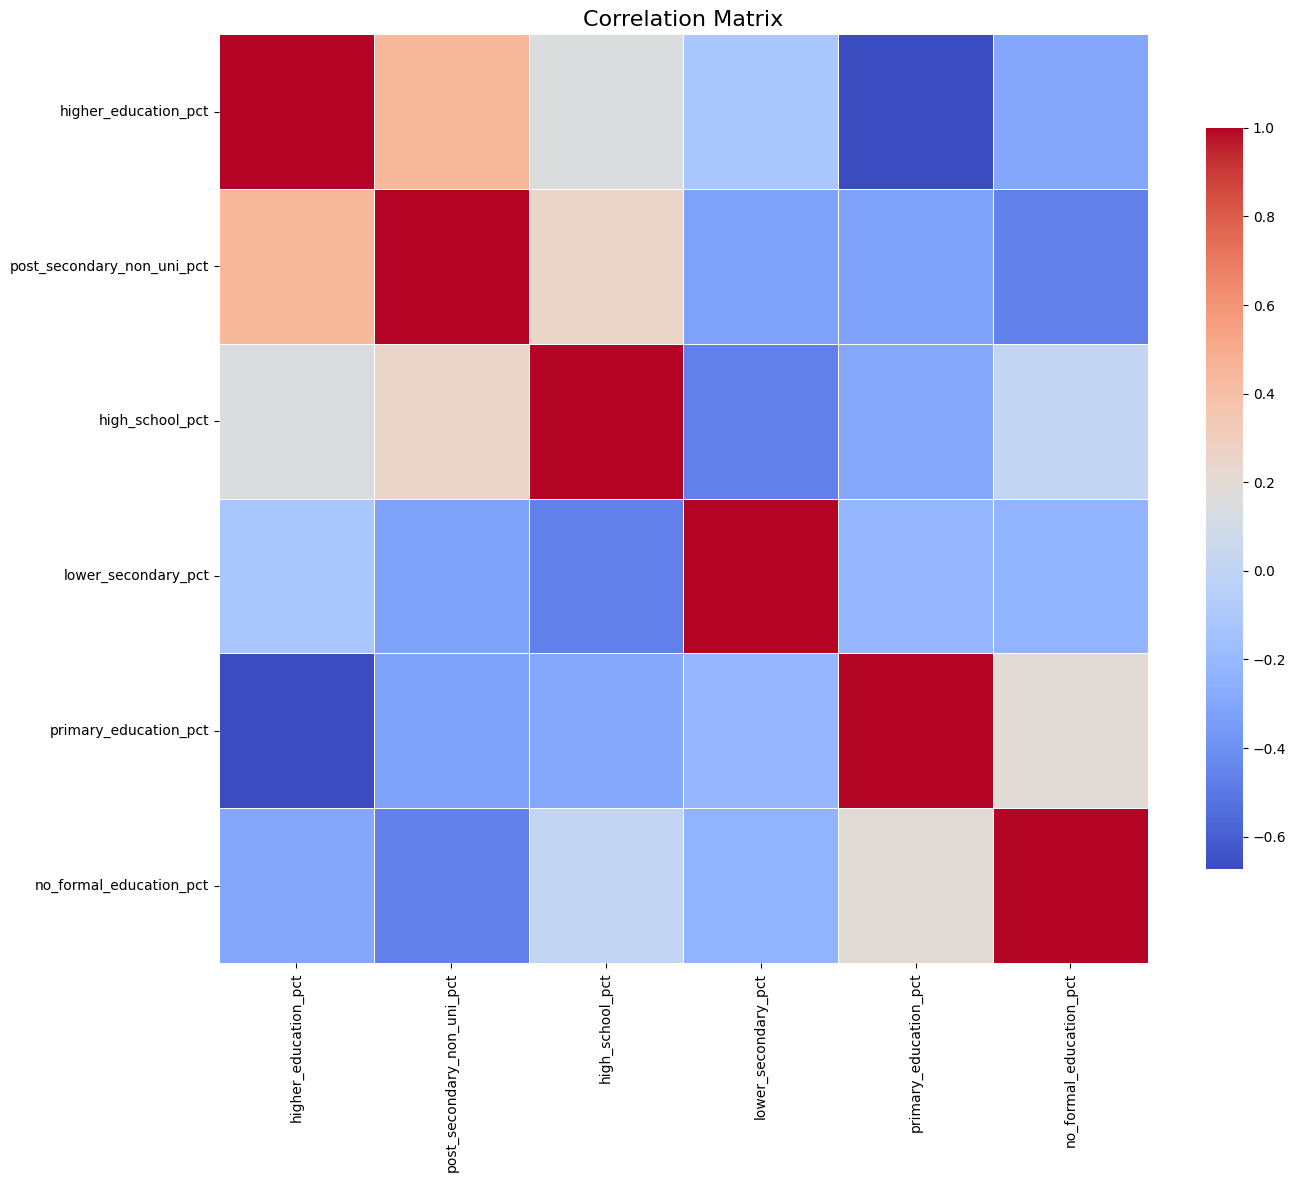

Total non-null correlation pairs: 15

No feature pairs with |correlation| ≥ 0.7.


In [56]:
EDA_correlation_matrix(df, output_file_name="4. correlations_education_level_groups.csv", features_subset=education_level_group_features, high_corr_threshold=0.7)

The correlation matrix confirms ***almost perfect*** multicollinearity among the education level group features, specifically:
- **Strong negative correlations between distant age groups**: higher_education_pct/primary_education_pct: r = -0.97, which is expected due to the composational age group  that they belong to

#### ***Marriage-Status Groups***

In [57]:
marriage_status_group_features = ['Άγαμοι_pct',
       'Έγγαμοι_pct', 'Χήροι_pct', 'Διαζευγμένοι_pct'
]

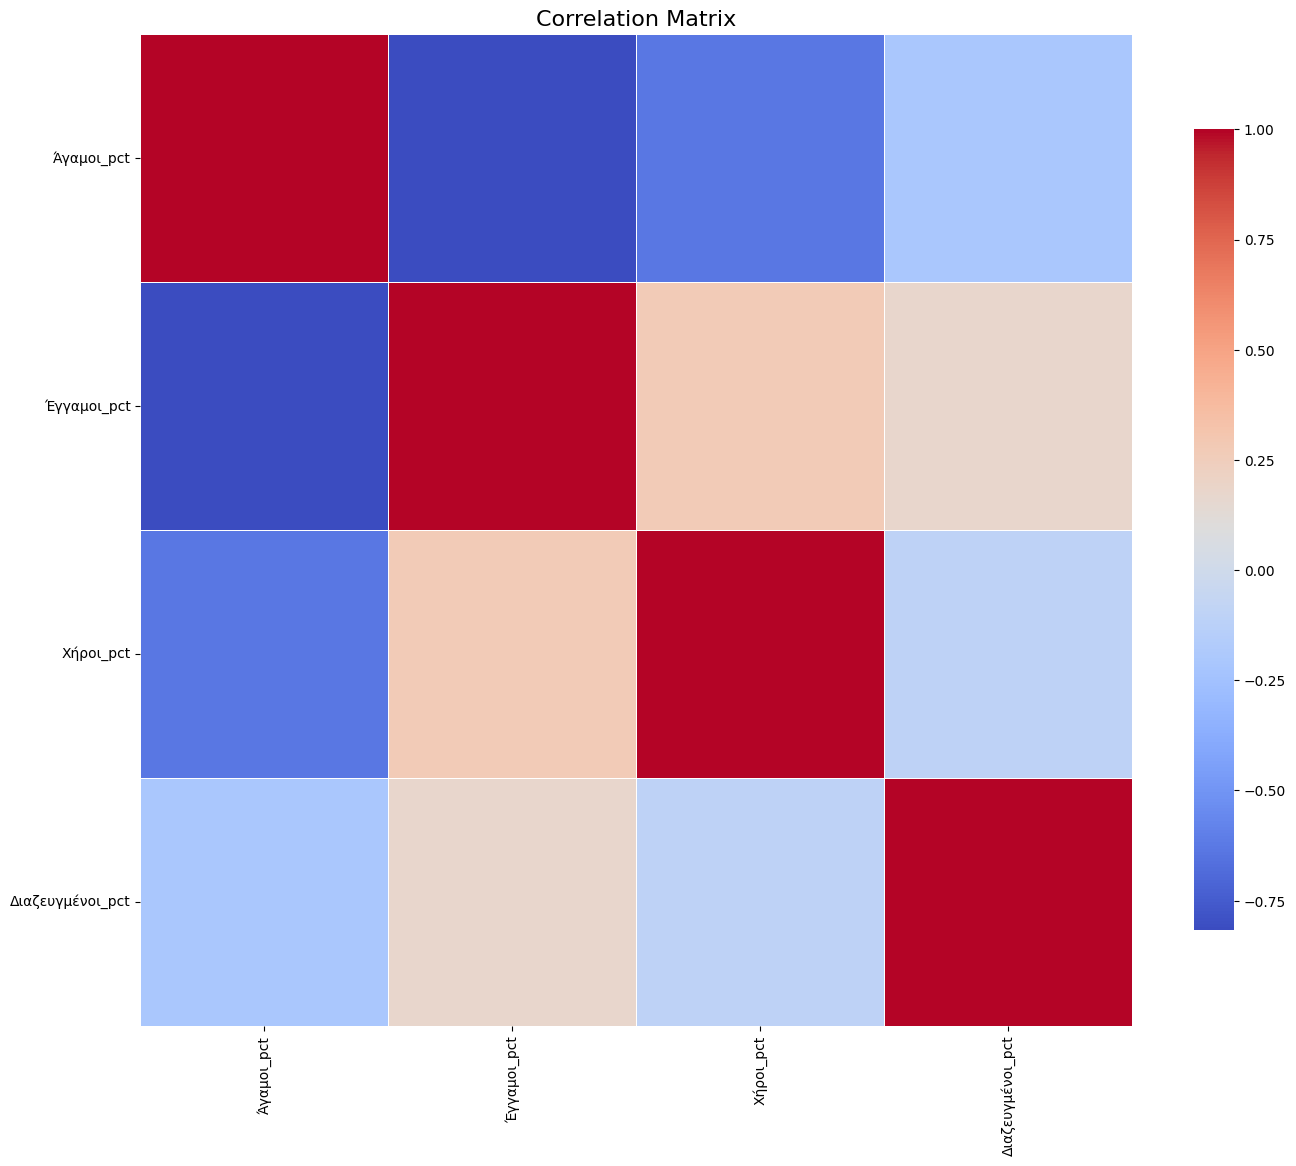

Total non-null correlation pairs: 6

Found 1 highly correlated feature pairs (|correlation| ≥ 0.7):
 Feature 1   Feature 2  Correlation
Άγαμοι_pct Έγγαμοι_pct    -0.816801


In [58]:
EDA_correlation_matrix(df, output_file_name="5. correlations_marriage_status_groups.csv", features_subset=marriage_status_group_features, high_corr_threshold=0.7)

The correlation matrix confirms not as extreme but still significant multicollinearity among the education level group features, specifically:
- **Strong negative correlations between distant age groups**: Άγαμοι_pct/Έγγαμοι_pct: r = -0.82, which is expected due to the composational age group  that they belong to

#### ***Hierarchical Economic Groups***

In [59]:
hierarchical_economic_group_features = ['Οικονομικά ενεργοί',
       'Απασχολούμενοι', 'Πρωτογενής', 'Δευτερογενής', 'Τριτογενής', 'Άνεργοι',
       'Οικονομικά μη ενεργοί'
]

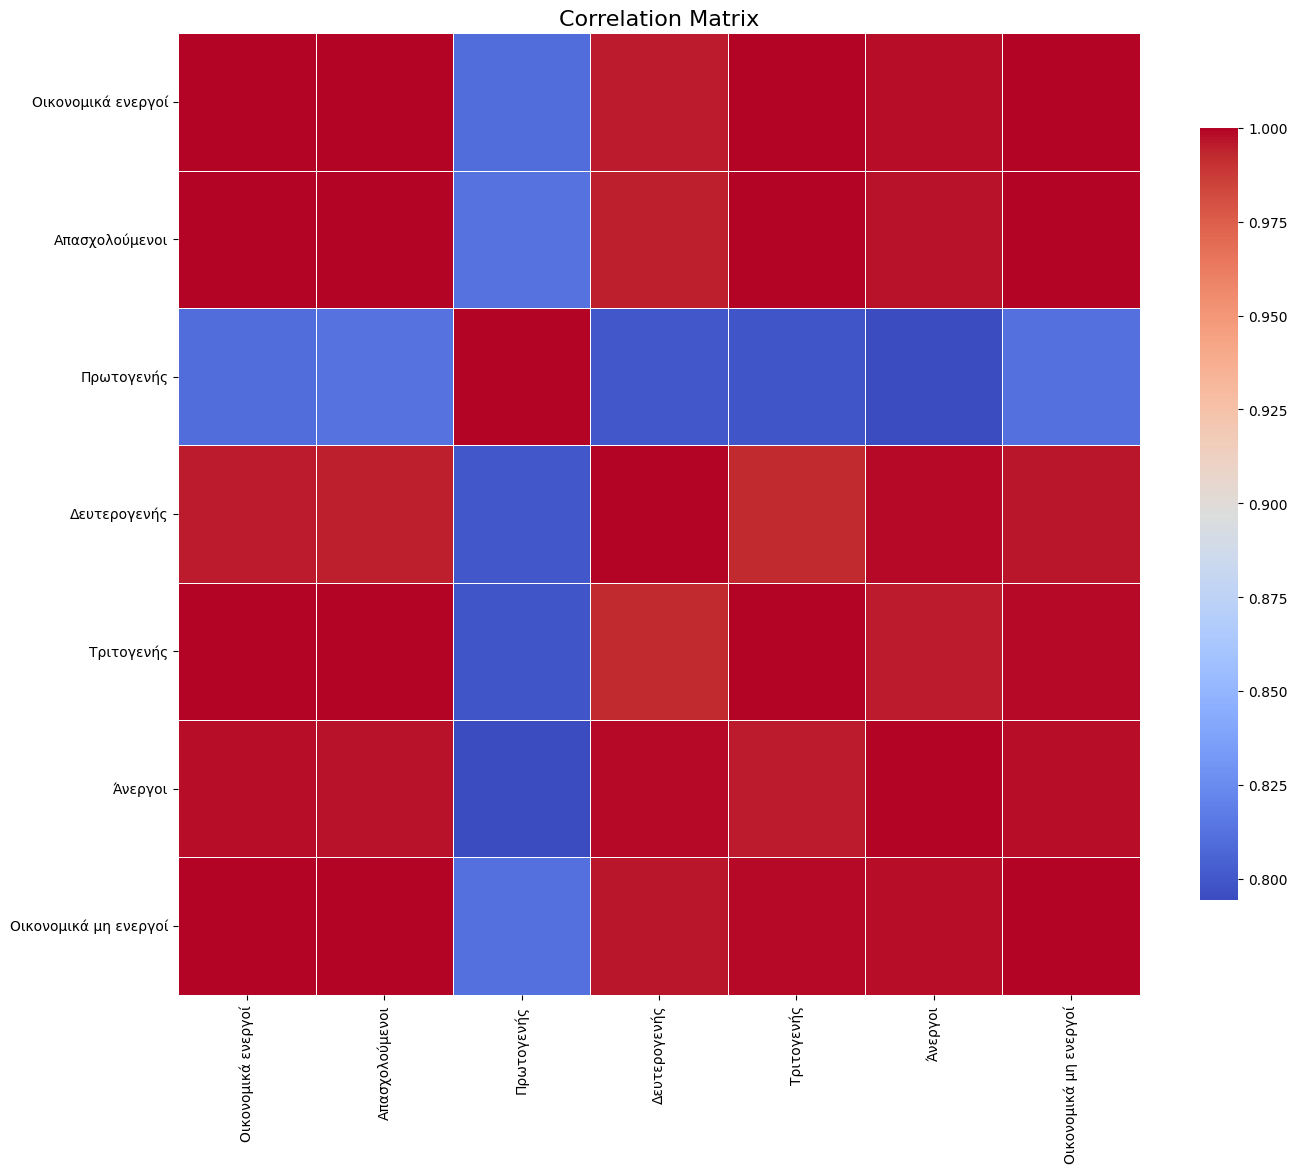

Total non-null correlation pairs: 21

Found 21 highly correlated feature pairs (|correlation| ≥ 0.7):
         Feature 1             Feature 2  Correlation
Οικονομικά ενεργοί        Απασχολούμενοι     0.999924
Οικονομικά ενεργοί Οικονομικά μη ενεργοί     0.999857
    Απασχολούμενοι Οικονομικά μη ενεργοί     0.999722
    Απασχολούμενοι            Τριτογενής     0.999474
Οικονομικά ενεργοί            Τριτογενής     0.999265
      Δευτερογενής               Άνεργοι     0.998797
        Τριτογενής Οικονομικά μη ενεργοί     0.998795
           Άνεργοι Οικονομικά μη ενεργοί     0.998006
Οικονομικά ενεργοί               Άνεργοι     0.997825
    Απασχολούμενοι               Άνεργοι     0.996939
      Δευτερογενής Οικονομικά μη ενεργοί     0.996324
Οικονομικά ενεργοί          Δευτερογενής     0.995655
        Τριτογενής               Άνεργοι     0.995577
    Απασχολούμενοι          Δευτερογενής     0.994586
      Δευτερογενής            Τριτογενής     0.992125
    Απασχολούμενοι            Πρωτ

In [60]:
EDA_correlation_matrix(df, output_file_name="6. correlations_hierarchical_economic_groups.csv", features_subset=hierarchical_economic_group_features, high_corr_threshold=0.7)

These relationships stem from hierarchical definitions which introduce ***perfect multicollinearity***. To solve, this derived indicators like unemployment_rate, labor_force_participation_rate, and sector percentages were computed and used in further analysis

The original file 'ELSTAT-demographic.csv' contained the values about the demographic features. Now I will create a new file that contains them as ***percentages***, because I believe this will be better for a ML model later

In [61]:
education_cols = [
    'higher_education', 'post_secondary_non_uni', 'high_school',
    'lower_secondary', 'primary_education', 'no_formal_education'
]

age_cols = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
            '35-39','40-44','45-49','50-54','55-59','60-64','65-69',
            '70-74','75+'
]

marital_cols = ['Άγαμοι', 'Έγγαμοι', 'Χήροι', 'Διαζευγμένοι']

## ***Individual Feature Inspection***

Now let's inspect the features that we obtained by joining the business entries with their corresponding ***Municipal Communities***. In this case, I should inspect some of these features based on the 'ELSTAT-demographic-economic.csv' file to get a better understanding.

### ***Feature: ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ***


Column: ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ
Number of unique values: 1
Sample unique values: ['ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ']

Most common values in 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ':
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ    76
Name: count, dtype: int64


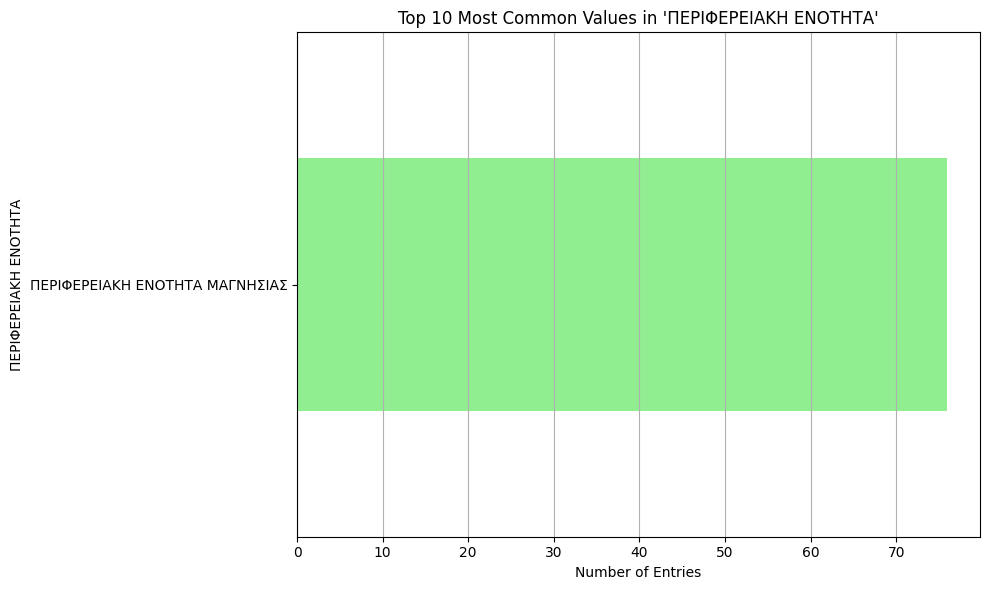

In [62]:
inspect_distribution_categorical(df, 'ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ', color='lightgreen')

### ***Feature: ΔΗΜΟΣ***


Column: ΔΗΜΟΣ
Number of unique values: 5
Sample unique values: ['ΔΗΜΟΣ ΒΟΛΟΥ' 'ΔΗΜΟΣ ΑΛΜΥΡΟΥ' 'ΔΗΜΟΣ ΖΑΓΟΡΑΣ - ΜΟΥΡΕΣΙΟΥ'
 'ΔΗΜΟΣ ΝΟΤΙΟΥ ΠΗΛΙΟΥ' 'ΔΗΜΟΣ ΡΗΓΑ ΦΕΡΑΙΟΥ']

Most common values in 'ΔΗΜΟΣ':
ΔΗΜΟΣ
ΔΗΜΟΣ ΒΟΛΟΥ                  22
ΔΗΜΟΣ ΑΛΜΥΡΟΥ                18
ΔΗΜΟΣ ΝΟΤΙΟΥ ΠΗΛΙΟΥ          17
ΔΗΜΟΣ ΡΗΓΑ ΦΕΡΑΙΟΥ           10
ΔΗΜΟΣ ΖΑΓΟΡΑΣ - ΜΟΥΡΕΣΙΟΥ     9
Name: count, dtype: int64


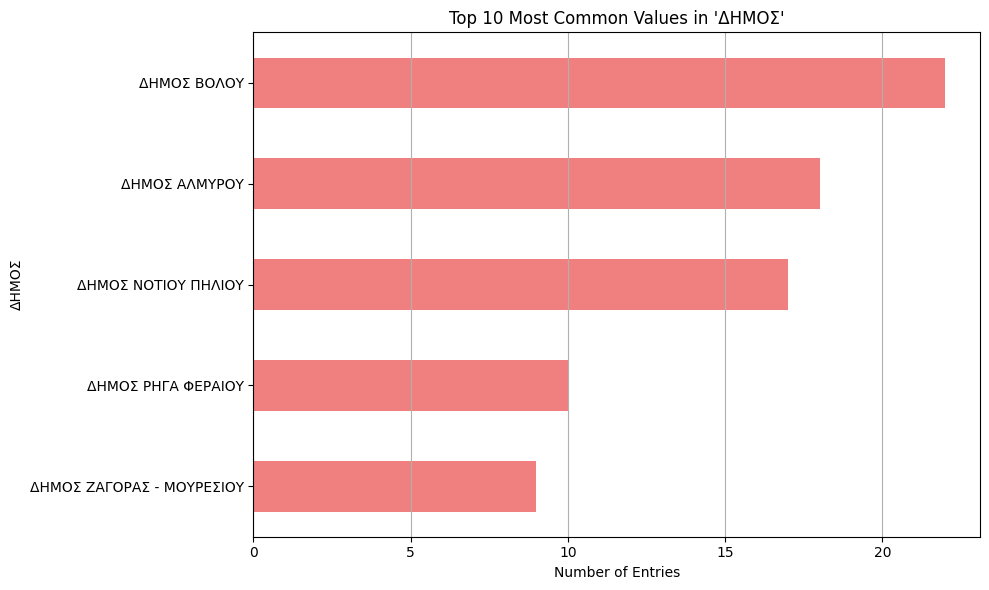

In [63]:
inspect_distribution_categorical(df, 'ΔΗΜΟΣ', color='lightcoral', top_n=10)

### ***Feature: ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ***

The feature 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ' is right above 'Municipal_Community' hierarchically, so we expect to get some different values here. Nevertheless, this feature will likely be ***not used***


Column: ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ
Number of unique values: 23
Sample unique values: ['ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ' 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ'
 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ' 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΡΤΕΜΙΔΑΣ'
 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΙΩΛΚΟΥ' 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΜΑΚΡΙΝΙΤΣΗΣ'
 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΝΕΑΣ ΑΓΧΙΑΛΟΥ' 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΝΕΑΣ ΙΩΝΙΑΣ'
 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΠΟΡΤΑΡΙΑΣ' 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΛΜΥΡΟΥ']

Most common values in 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ':
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΛΜΥΡΟΥ          8
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΣΟΥΡΠΗΣ          6
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΜΟΥΡΕΣΙΟΥ        6
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΜΗΛΕΩΝ           5
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΦΕΤΩΝ           5
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΦΕΡΩΝ            5
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΡΤΕΜΙΔΑΣ        4
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΚΑΡΛΑΣ           4
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΠΟΡΤΑΡΙΑΣ        4
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΡΓΑΛΑΣΤΗΣ       3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΖΑΓΟΡΑΣ          3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΠΤΕΛΕΟΥ          3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΝΕΑΣ ΑΓΧΙΑΛΟΥ    3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΙΩΛΚΟΥ           3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΣΗΠΙΑΔΟΣ         3
ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ          

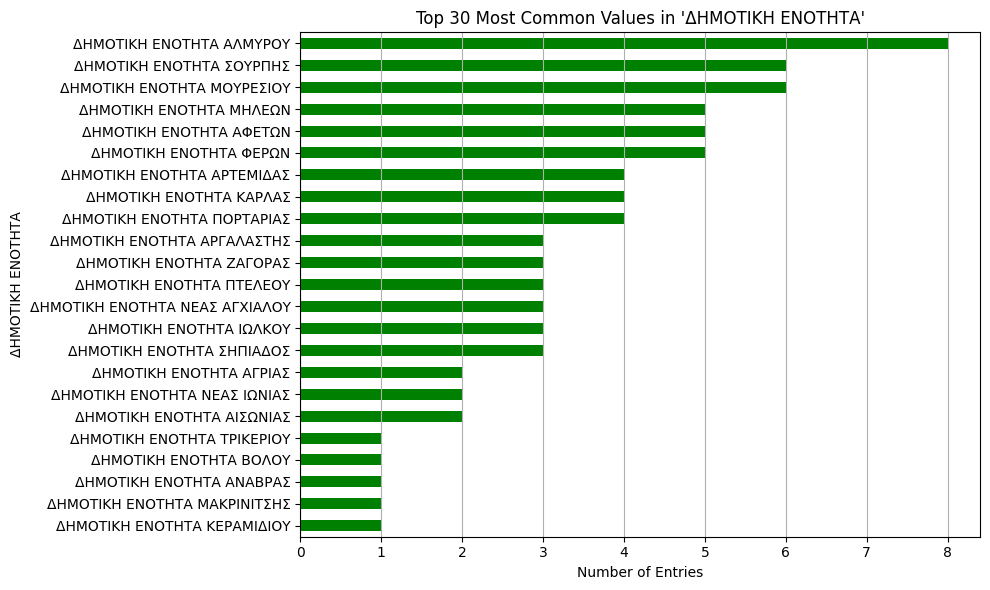

In [64]:
inspect_distribution_categorical(df, 'ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ', color='green', top_n=30)

### ***Feature: Population***

We see that ***'Δημοτική Κοινότητα Βόλου'*** has a large gap as the most populated Municipal Community ***'Δημοτική Κοινότητα Νέας Ιωνίας'***, and then other smaller ones


Column: Population
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

Population statistics (non-null):
count       76.000000
mean      2333.776316
std      10396.207249
min         12.000000
25%        247.750000
50%        438.500000
75%        901.500000
max      85806.000000
Name: Population, dtype: float64


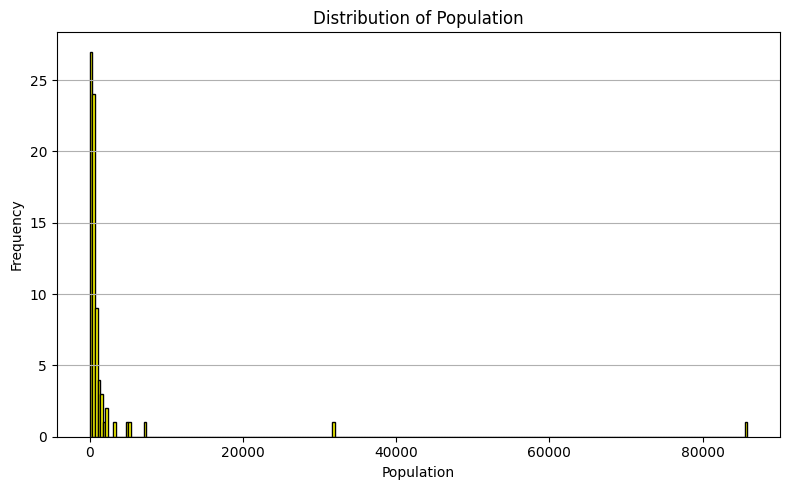

In [65]:
inspect_distribution_numerical(df, 'Population', color='yellow', bins=255)

In [66]:
print_top_n_largest(df, column='Population', community_col='ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ', n=20)


Top 20 largest values in 'Population' by Municipal Community:

                       ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ  Population
                 Δημοτική Κοινότητα Βόλου       85806
           Δημοτική Κοινότητα Νέας Ιωνίας       31683
               Δημοτική Κοινότητα Αλμυρού        7404
         Δημοτική Κοινότητα Νέας Αγχιάλου        5113
                Δημοτική Κοινότητα Αγριάς        4926
            Δημοτική Κοινότητα Βελεστίνου        3201
              Δημοτική Κοινότητα Διμηνίου        2101
        Δημοτική Κοινότητα Ευξεινουπόλεως        2078
               Δημοτική Κοινότητα Ζαγοράς        1982
        Δημοτική Κοινότητα Στεφανοβικείου        1470
         Δημοτική Κοινότητα Κάτω Λεχωνίων        1410
            Δημοτική Κοινότητα Αργαλαστής        1395
               Δημοτική Κοινότητα Σούρπης        1336
          Δημοτική Κοινότητα Άνω Λεχωνίων        1250
             Δημοτική Κοινότητα Ριζομύλου        1214
               Δημοτική Κοινότητα Πτελεού        1196
             Δημοτ

### ***Feature: Age_Group_{i}_pct***

We will inspect each age group indiviually for now, and later see their relationships. I use 1 cell with a loop that includes them all:

These features are ***not hierarchical***, that add up to 1

In [67]:
age_columns = [
    '0-4_pct', '5-9_pct', '10-14_pct', '15-19_pct',
    '20-24_pct', '25-29_pct', '30-34_pct', '35-39_pct',
    '40-44_pct', '45-49_pct', '50-54_pct', '55-59_pct',
    '60-64_pct', '65-69_pct', '70-74_pct', '75+_pct'
]

Average proportion per age group:
0-4_pct      0.032288
5-9_pct      0.032666
10-14_pct    0.043486
15-19_pct    0.041012
20-24_pct    0.040011
25-29_pct    0.043174
30-34_pct    0.047504
35-39_pct    0.057499
40-44_pct    0.063870
45-49_pct    0.068085
50-54_pct    0.074130
55-59_pct    0.070189
60-64_pct    0.079112
65-69_pct    0.068135
70-74_pct    0.067218
75+_pct      0.170047


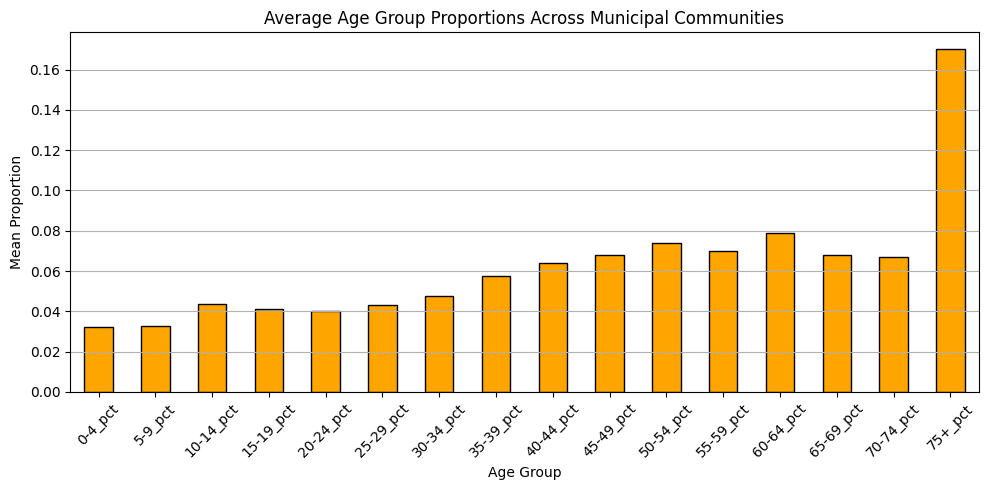

In [68]:
# plot the average age-group percentage per all the municipal communities
plot_group_means(df, age_columns, color='orange')


Column: 0-4_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

0-4_pct statistics (non-null):
count    76.000000
mean      0.032288
std       0.018687
min       0.000000
25%       0.020991
50%       0.029374
75%       0.041176
max       0.094340
Name: 0-4_pct, dtype: float64


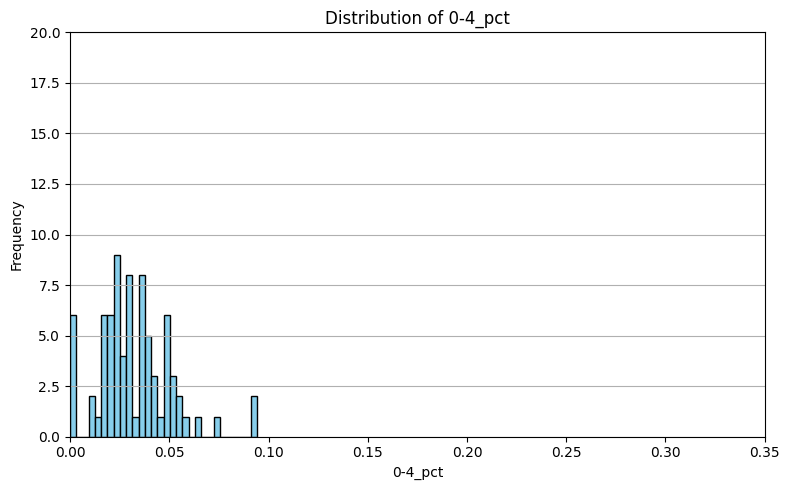


Column: 5-9_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

5-9_pct statistics (non-null):
count    76.000000
mean      0.032666
std       0.015780
min       0.000000
25%       0.024136
50%       0.034004
75%       0.042193
max       0.082079
Name: 5-9_pct, dtype: float64


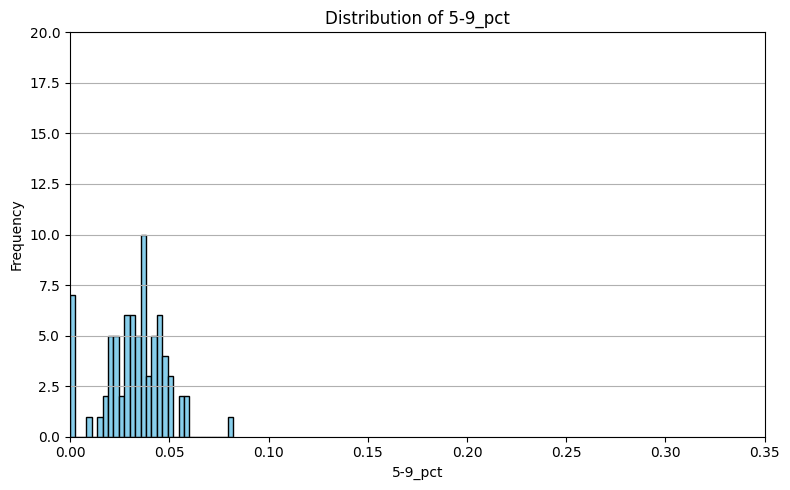


Column: 10-14_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

10-14_pct statistics (non-null):
count    76.000000
mean      0.043486
std       0.018082
min       0.000000
25%       0.035191
50%       0.046096
75%       0.056412
max       0.084416
Name: 10-14_pct, dtype: float64


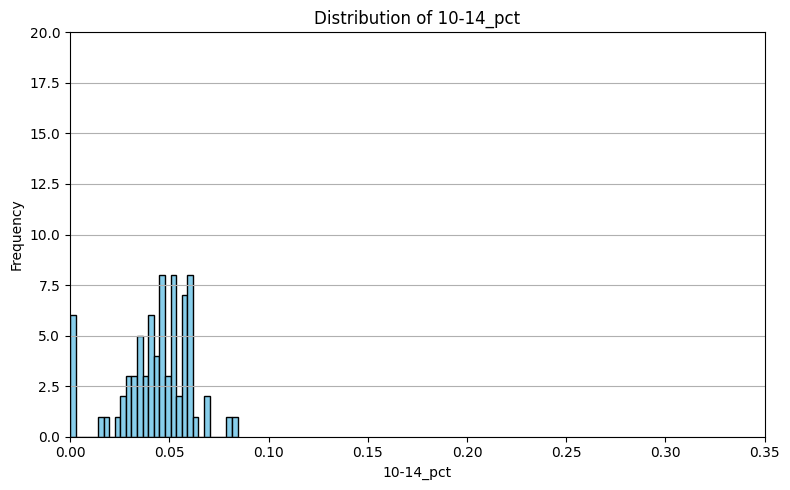


Column: 15-19_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

15-19_pct statistics (non-null):
count    76.000000
mean      0.041012
std       0.018889
min       0.000000
25%       0.030043
50%       0.044319
75%       0.053394
max       0.087819
Name: 15-19_pct, dtype: float64


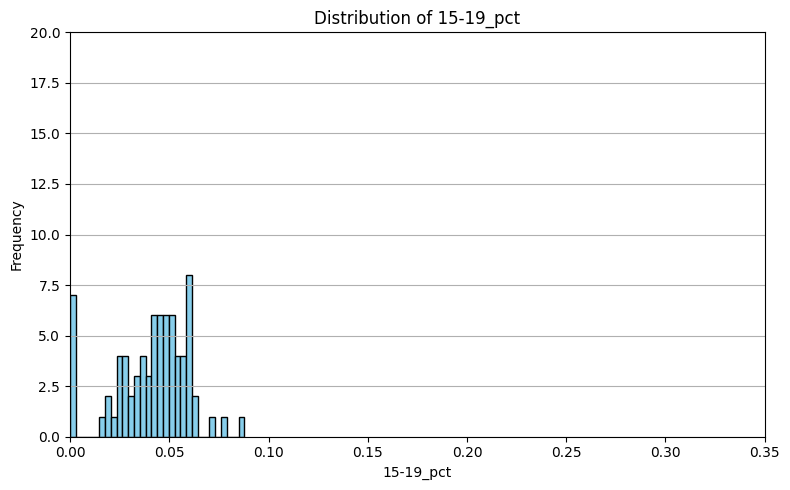


Column: 20-24_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

20-24_pct statistics (non-null):
count    76.000000
mean      0.040011
std       0.017326
min       0.000000
25%       0.033459
50%       0.039838
75%       0.049460
max       0.104513
Name: 20-24_pct, dtype: float64


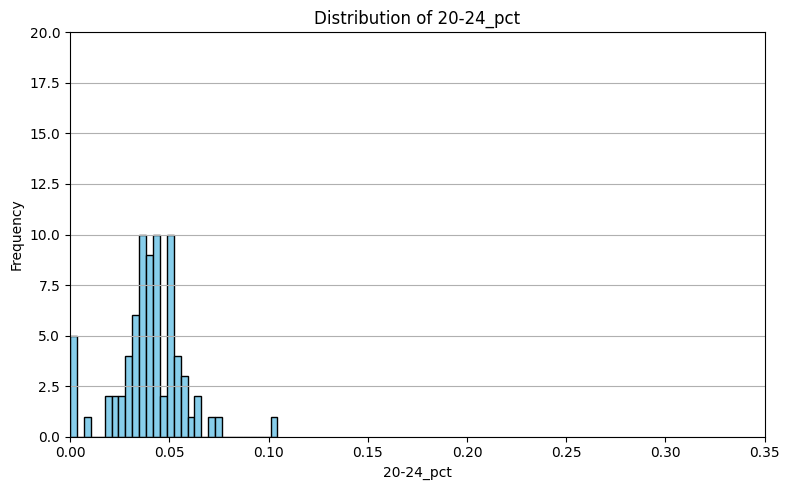


Column: 25-29_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

25-29_pct statistics (non-null):
count    76.000000
mean      0.043174
std       0.016545
min       0.000000
25%       0.033130
50%       0.042312
75%       0.052815
max       0.090909
Name: 25-29_pct, dtype: float64


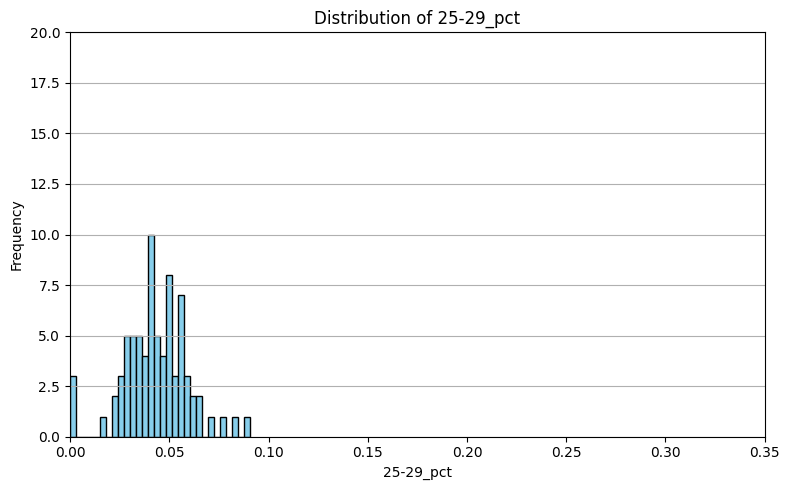


Column: 30-34_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

30-34_pct statistics (non-null):
count    76.000000
mean      0.047504
std       0.021477
min       0.000000
25%       0.037066
50%       0.044135
75%       0.055571
max       0.181818
Name: 30-34_pct, dtype: float64


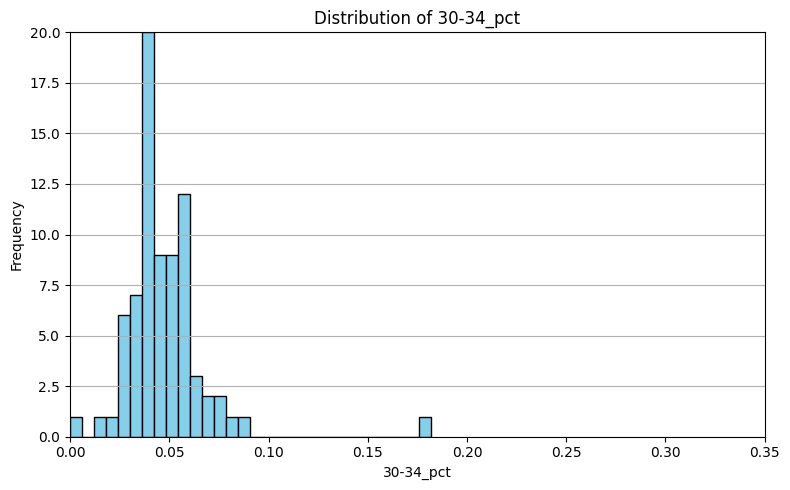


Column: 35-39_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

35-39_pct statistics (non-null):
count    76.000000
mean      0.057499
std       0.026414
min       0.000000
25%       0.044354
50%       0.055753
75%       0.066086
max       0.227273
Name: 35-39_pct, dtype: float64


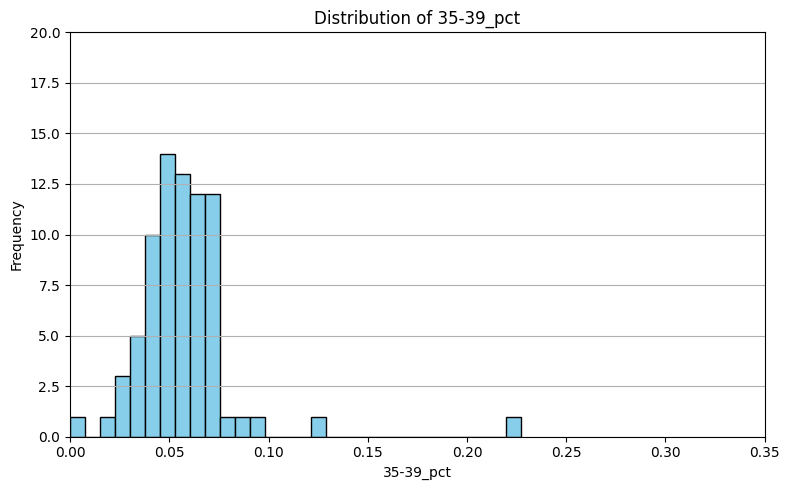


Column: 40-44_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

40-44_pct statistics (non-null):
count    76.000000
mean      0.063870
std       0.021256
min       0.000000
25%       0.054768
50%       0.067528
75%       0.077173
max       0.111111
Name: 40-44_pct, dtype: float64


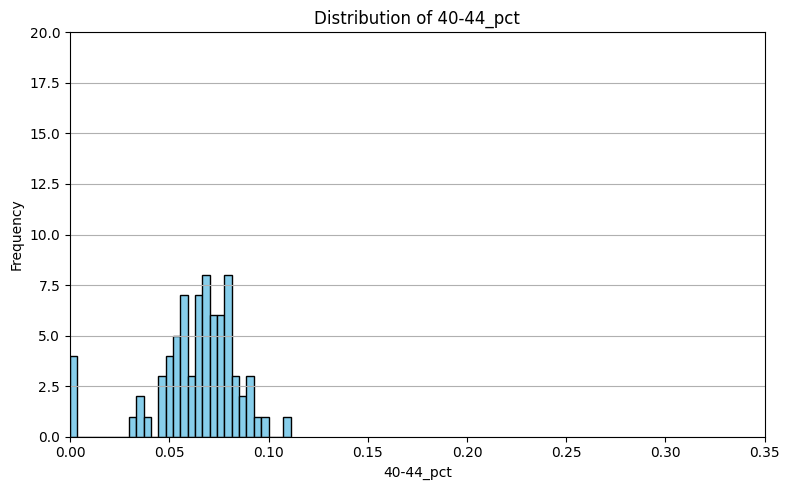


Column: 45-49_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

45-49_pct statistics (non-null):
count    76.000000
mean      0.068085
std       0.020348
min       0.000000
25%       0.059230
50%       0.072402
75%       0.078483
max       0.111111
Name: 45-49_pct, dtype: float64


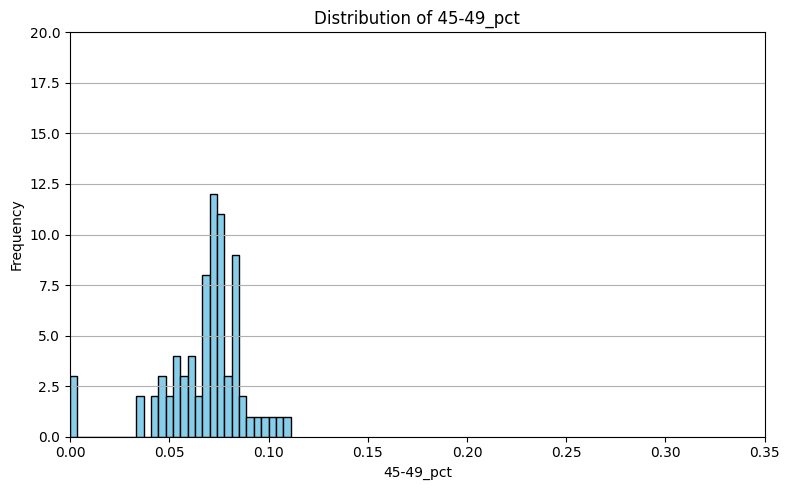


Column: 50-54_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

50-54_pct statistics (non-null):
count    76.000000
mean      0.074130
std       0.022790
min       0.000000
25%       0.065148
50%       0.075337
75%       0.085673
max       0.132287
Name: 50-54_pct, dtype: float64


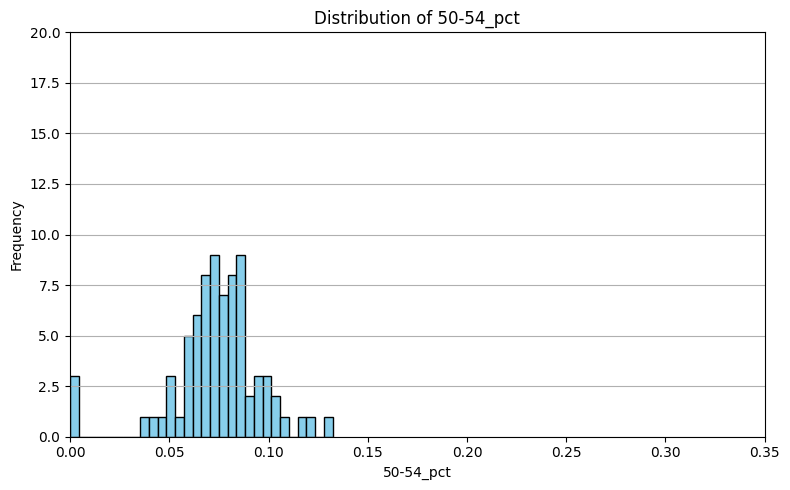


Column: 55-59_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

55-59_pct statistics (non-null):
count    76.000000
mean      0.070189
std       0.020978
min       0.000000
25%       0.061202
50%       0.071518
75%       0.080690
max       0.115254
Name: 55-59_pct, dtype: float64


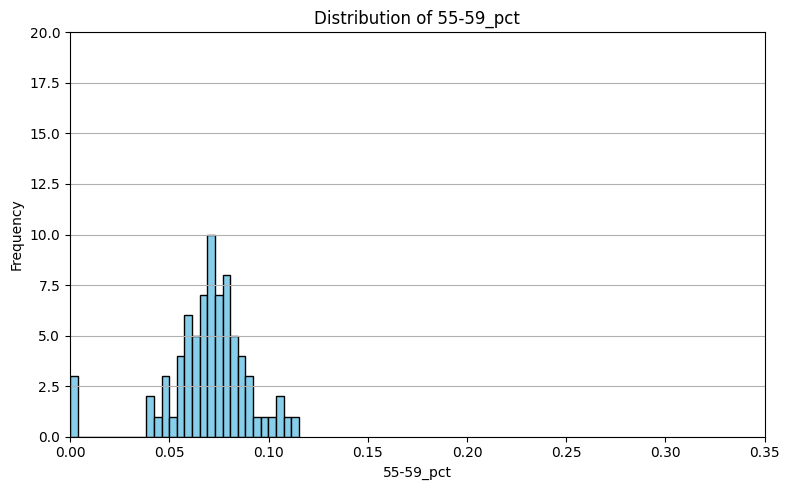


Column: 60-64_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

60-64_pct statistics (non-null):
count    76.000000
mean      0.079112
std       0.028953
min       0.000000
25%       0.065080
50%       0.076606
75%       0.087633
max       0.250000
Name: 60-64_pct, dtype: float64


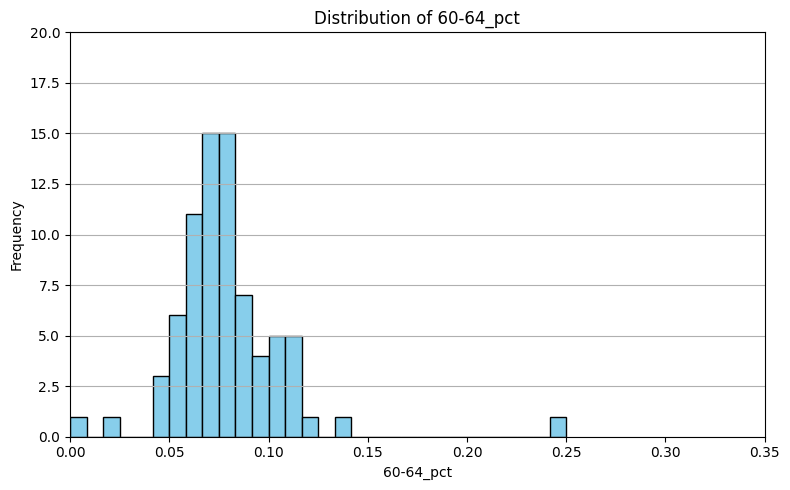


Column: 65-69_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

65-69_pct statistics (non-null):
count    76.000000
mean      0.068135
std       0.024285
min       0.000000
25%       0.056605
50%       0.066438
75%       0.080080
max       0.150943
Name: 65-69_pct, dtype: float64


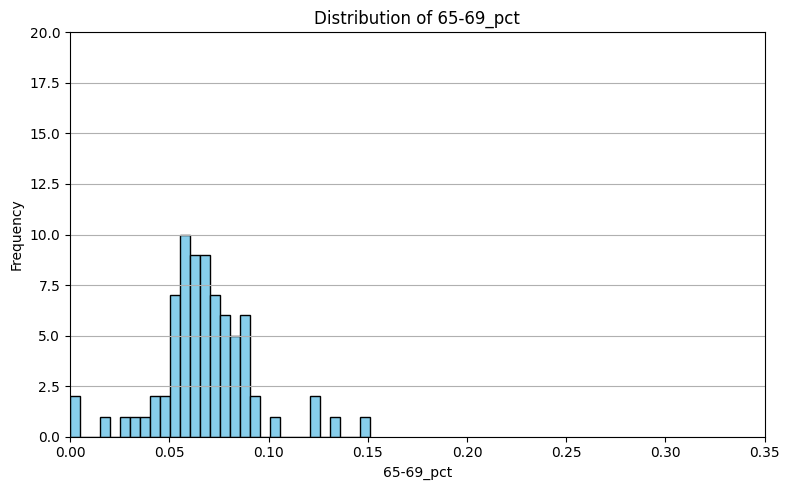


Column: 70-74_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

70-74_pct statistics (non-null):
count    76.000000
mean      0.067218
std       0.027238
min       0.000000
25%       0.052114
50%       0.064928
75%       0.075612
max       0.181818
Name: 70-74_pct, dtype: float64


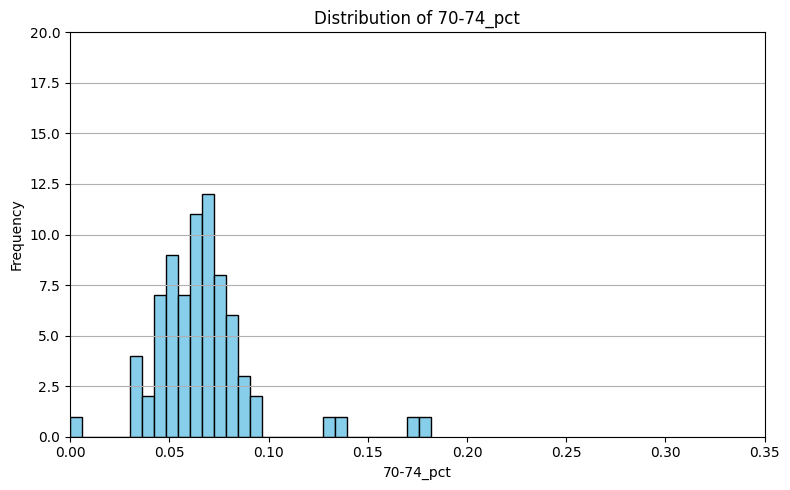


Column: 75+_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

75+_pct statistics (non-null):
count    76.000000
mean      0.170047
std       0.050859
min       0.074074
25%       0.134467
50%       0.166602
75%       0.195479
max       0.333333
Name: 75+_pct, dtype: float64


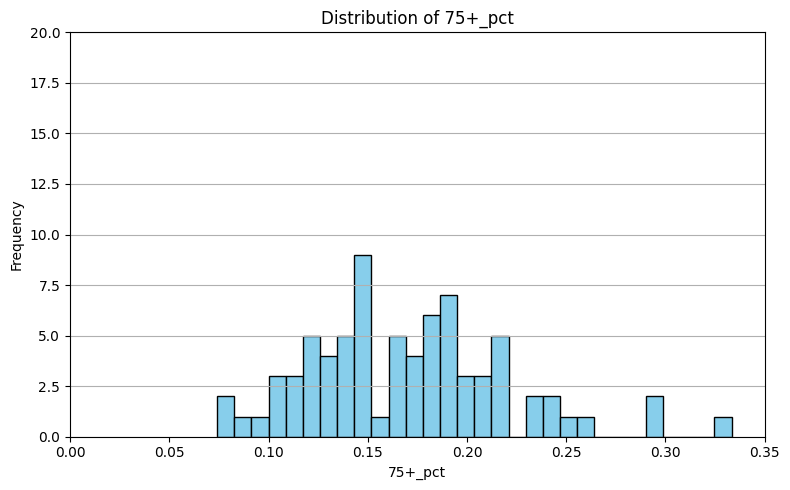

In [69]:
# inspect the distribution of each age-group individually
for col in age_columns:
    inspect_distribution_numerical(df, column=col, color='skyblue', bins=30, xlim=(0, 0.35), ylim=(0, 20))

### ***Feature: Education_Level_Group_{i}_pct***

These features are ***not hierarchical***, that add up to 1

In [70]:
education_level_columns = [
       'higher_education_pct','post_secondary_non_uni_pct', 
       'high_school_pct', 'lower_secondary_pct',
       'primary_education_pct', 'no_formal_education_pct'
]

Average proportion per age group:
higher_education_pct          0.136944
post_secondary_non_uni_pct    0.040077
high_school_pct               0.263060
lower_secondary_pct           0.151002
primary_education_pct         0.297506
no_formal_education_pct       0.111184


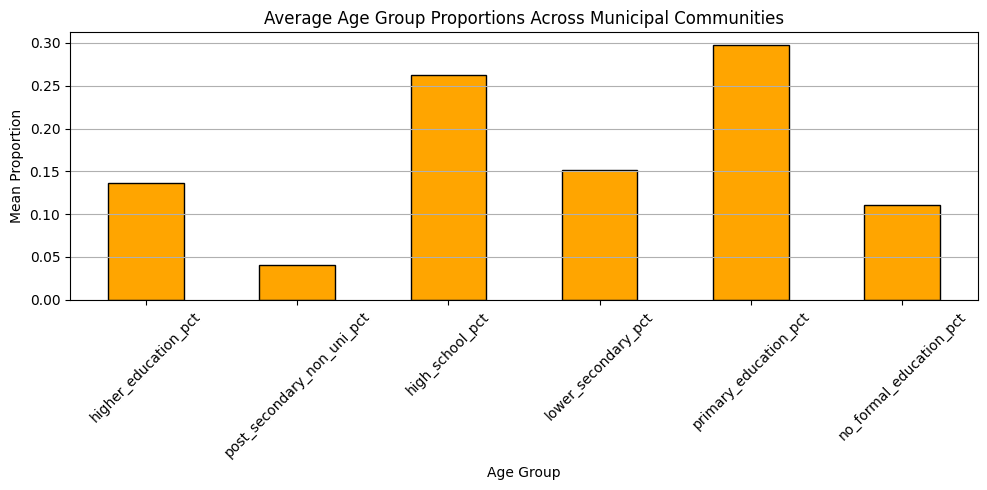

In [71]:
# plot the average education-level-group percentage per all the municipal communities
plot_group_means(df, education_level_columns, color='orange')


Column: higher_education_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

higher_education_pct statistics (non-null):
count    76.000000
mean      0.136944
std       0.062693
min       0.000000
25%       0.096873
50%       0.128581
75%       0.173350
max       0.348837
Name: higher_education_pct, dtype: float64


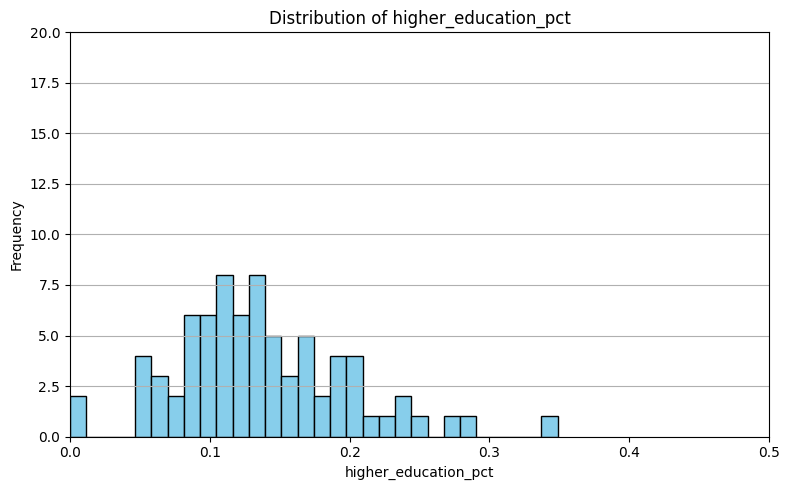


Column: post_secondary_non_uni_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

post_secondary_non_uni_pct statistics (non-null):
count    76.000000
mean      0.040077
std       0.024547
min       0.000000
25%       0.029622
50%       0.040996
75%       0.049850
max       0.181818
Name: post_secondary_non_uni_pct, dtype: float64


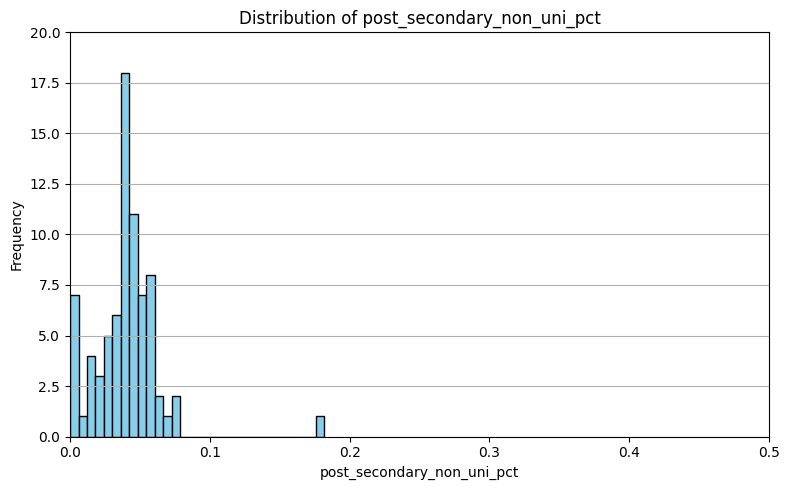


Column: high_school_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

high_school_pct statistics (non-null):
count    76.000000
mean      0.263060
std       0.053727
min       0.000000
25%       0.240846
50%       0.261687
75%       0.291160
max       0.409091
Name: high_school_pct, dtype: float64


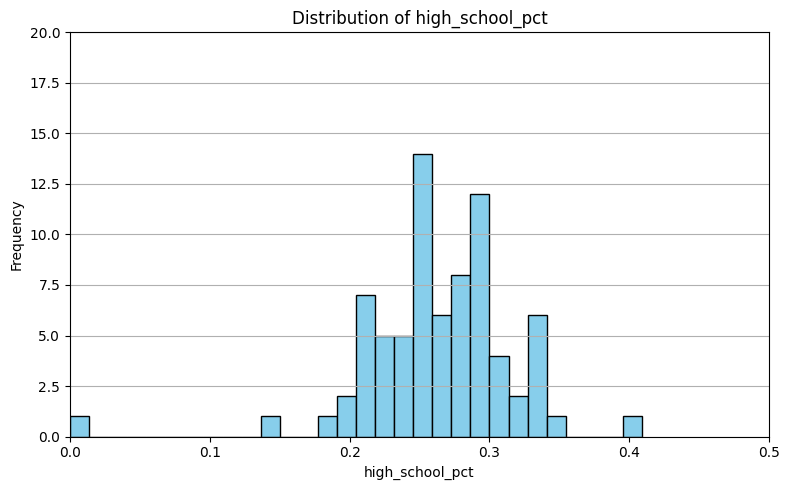


Column: lower_secondary_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

lower_secondary_pct statistics (non-null):
count    76.000000
mean      0.151002
std       0.044147
min       0.000000
25%       0.126432
50%       0.151693
75%       0.178019
max       0.333333
Name: lower_secondary_pct, dtype: float64


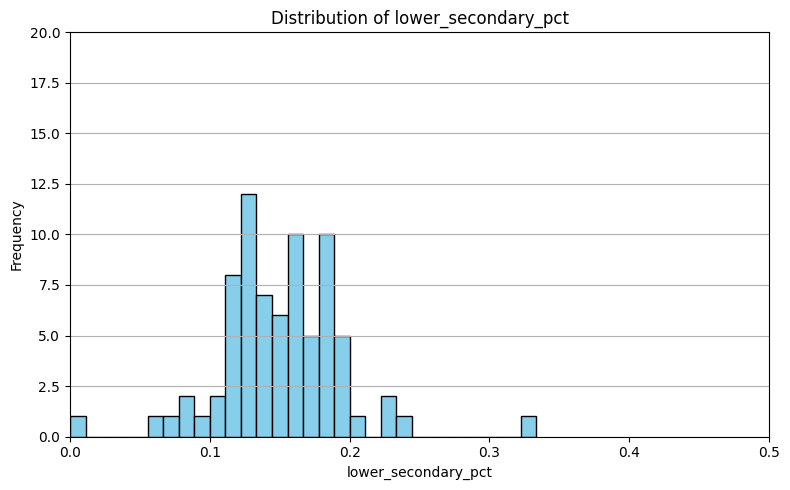


Column: primary_education_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

primary_education_pct statistics (non-null):
count    76.000000
mean      0.297506
std       0.075235
min       0.131783
25%       0.249879
50%       0.283372
75%       0.341276
max       0.500000
Name: primary_education_pct, dtype: float64


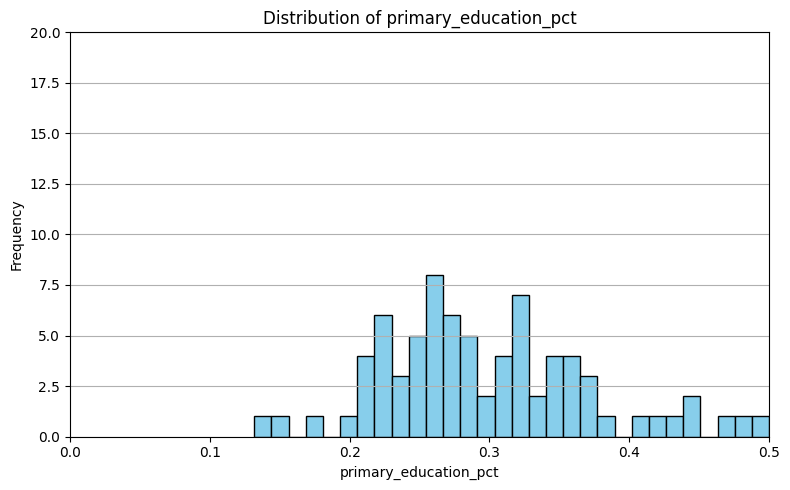


Column: no_formal_education_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

no_formal_education_pct statistics (non-null):
count    76.000000
mean      0.111184
std       0.038611
min       0.000000
25%       0.087455
50%       0.112035
75%       0.131180
max       0.206813
Name: no_formal_education_pct, dtype: float64


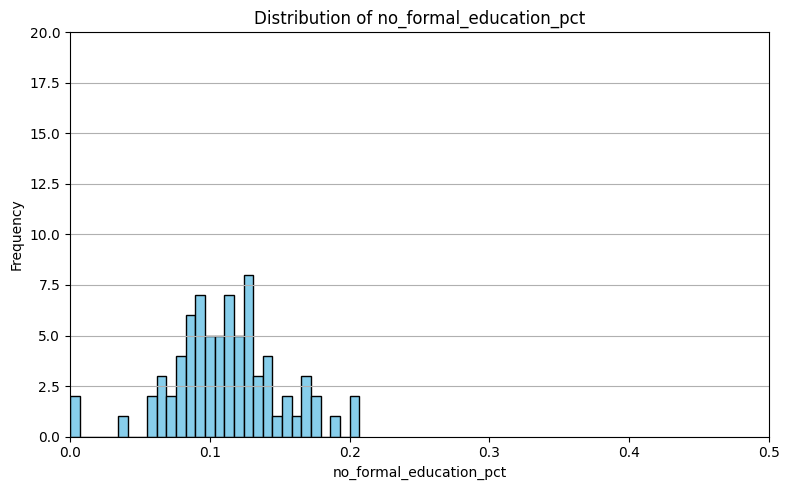

In [72]:
# inspect the distribution of each education-level-group individually
for col in education_level_columns:
    inspect_distribution_numerical(df, column=col, color='skyblue', bins=30, xlim=(0, 0.5), ylim=(0, 20))

### ***Feature: Marriage_Status_Group_{i}_pct***

These features are ***not hierarchical***, that add up to 1

In [73]:
marriage_status_columns = [
       'Άγαμοι_pct', 'Έγγαμοι_pct', 
       'Χήροι_pct', 'Διαζευγμένοι_pct'
]

Average proportion per age group:
Άγαμοι_pct          0.359377
Έγγαμοι_pct         0.488910
Χήροι_pct           0.107847
Διαζευγμένοι_pct    0.037587


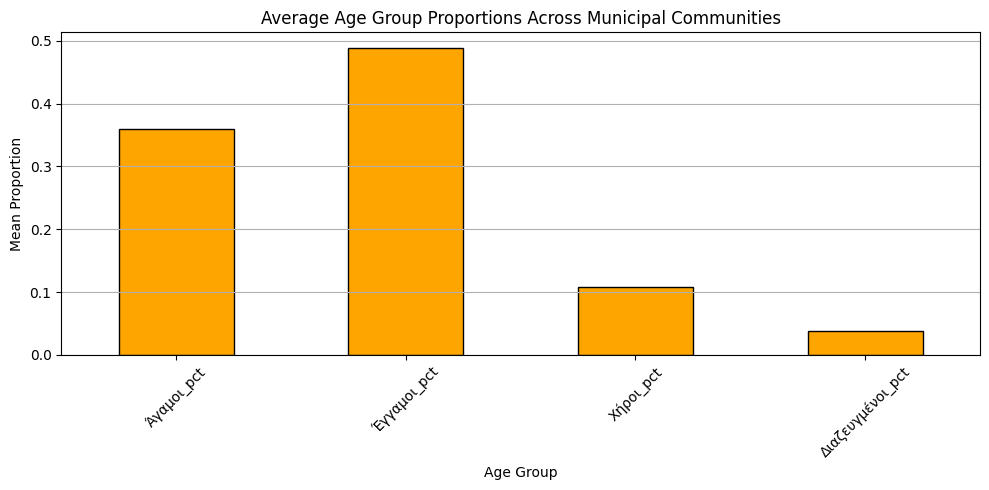

In [74]:
# plot the average marriage-status-group percentage per all the municipal communities
plot_group_means(df, marriage_status_columns, color='orange')


Column: Άγαμοι_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

Άγαμοι_pct statistics (non-null):
count    76.000000
mean      0.359377
std       0.061807
min       0.234375
25%       0.322867
50%       0.348686
75%       0.379340
max       0.750000
Name: Άγαμοι_pct, dtype: float64


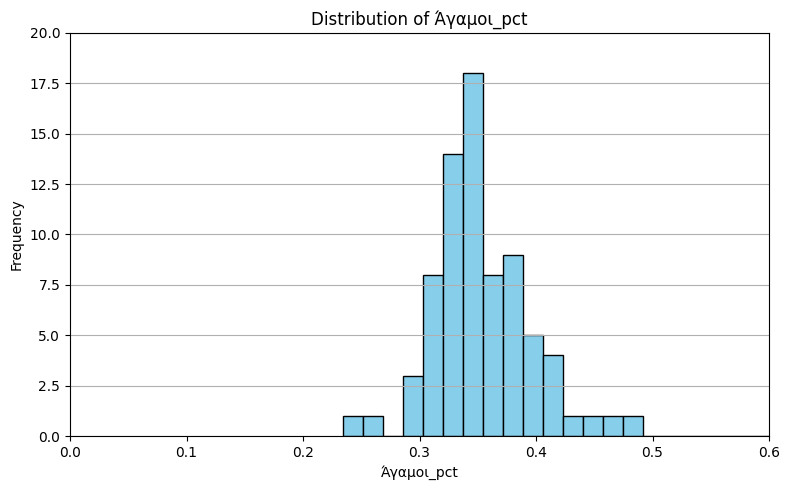


Column: Έγγαμοι_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

Έγγαμοι_pct statistics (non-null):
count    76.000000
mean      0.488910
std       0.068263
min       0.000000
25%       0.471210
50%       0.502141
75%       0.516524
max       0.587079
Name: Έγγαμοι_pct, dtype: float64


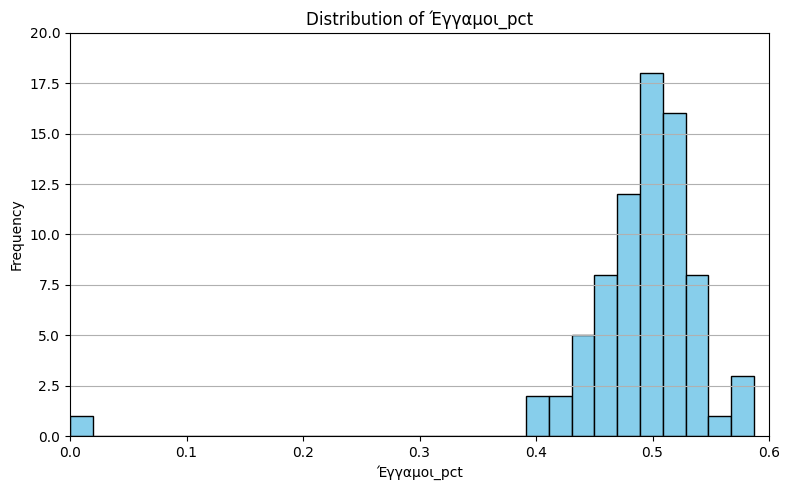


Column: Χήροι_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

Χήροι_pct statistics (non-null):
count    76.000000
mean      0.107847
std       0.031270
min       0.000000
25%       0.087532
50%       0.103337
75%       0.130254
max       0.178947
Name: Χήροι_pct, dtype: float64


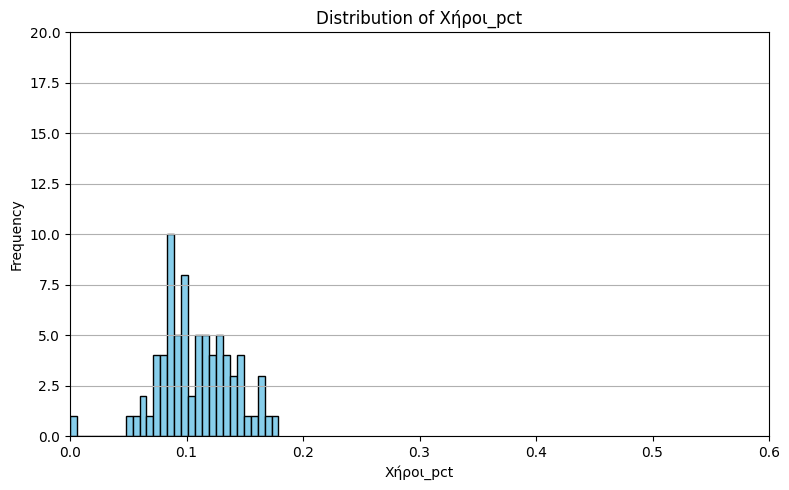


Column: Διαζευγμένοι_pct
Total entries: 76
Non-null values: 76
Missing values: 0 (0.00%)

Διαζευγμένοι_pct statistics (non-null):
count    76.000000
mean      0.037587
std       0.019187
min       0.000000
25%       0.025134
50%       0.036932
75%       0.050874
max       0.084337
Name: Διαζευγμένοι_pct, dtype: float64


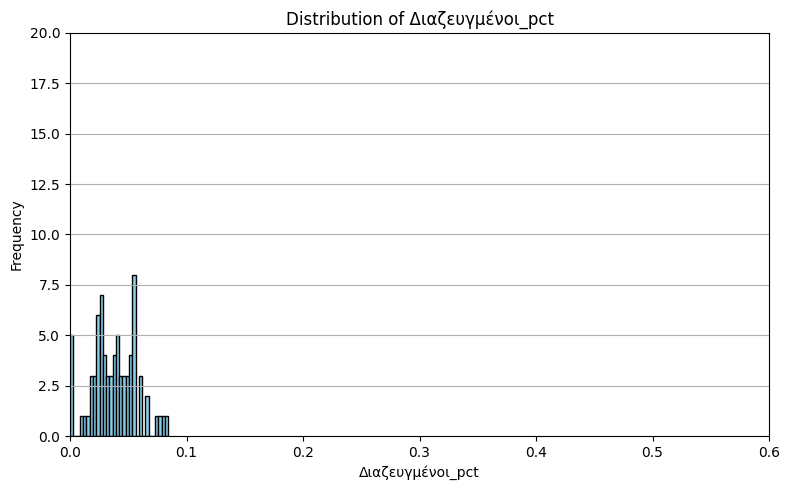

In [75]:
# inspect the distribution of each marriage-status-group individually
for col in marriage_status_columns:
    inspect_distribution_numerical(df, column=col, color='skyblue', bins=30, xlim=(0, 0.6), ylim=(0, 20))

### ***Feature: Hierarchical_Economic_Group_{i}***

These features are ***hierarchical***, with the followning srtucture: 

- 'Οικονομικά ενεργοί',
     -  'Απασχολούμενοι',
          - 'Πρωτογενής', 
          - 'Δευτερογενής'
          - 'Τριτογενής'
     -  'Άνεργοι',
- 'Οικονομικά μη ενεργοί'

Also, these values are ***not percentages***, they are the legit values

In [82]:
check_hierarchical_data_consistency(df)

Maximum errors per category:
  Sector sum vs Employed:         8.00
  Employed + Unemployed vs Active:4.00

Rows with inconsistencies (errors > 5 people):


,sector_error,active_error,total_people
0,0,2,85803
1,1,3,4929
2,0,2,366
3,1,2,2103
4,0,2,897
...,...,...,...
71,5,3,1466
72,4,2,893
73,6,2,192
74,5,4,1210


We see that there is a ***high consistency*** for our hierarchical data, as these errors are well within tolerance for practical use.

In [83]:
hierarchical_economic_columns = [
    'Οικονομικά ενεργοί', 'Απασχολούμενοι', 'Πρωτογενής',
    'Δευτερογενής', 'Τριτογενής', 'Άνεργοι', 'Οικονομικά μη ενεργοί'
]

The following plot showcases the means of these features, while displaying their hierarchical nature. We see that there are ***more inactive than active*** people! --> this could be related to the high percentage of high-age groups.

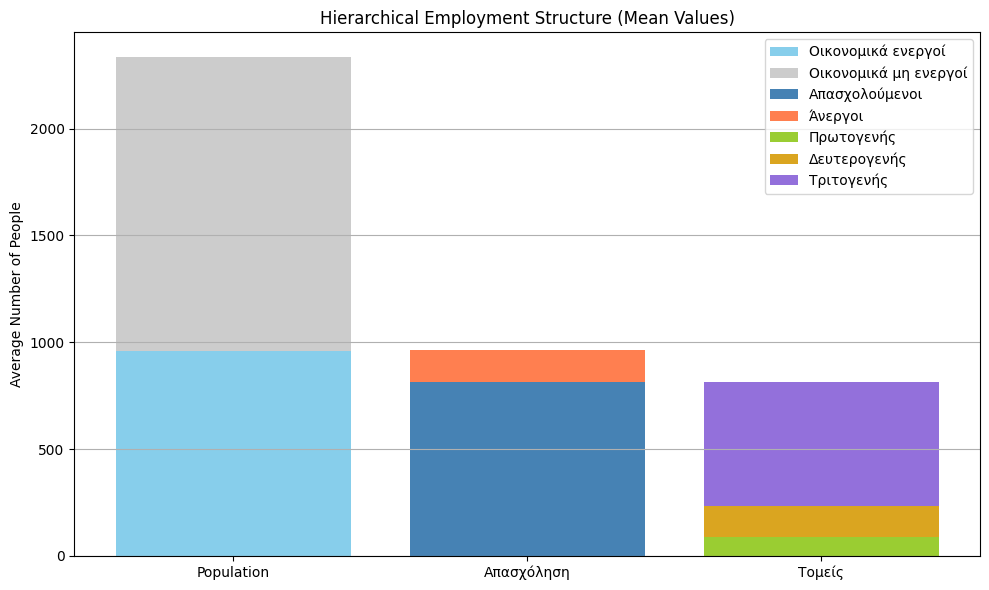

In [84]:
plot_economic_hierarchy_means(df)

Average proportion per age group:
Οικονομικά ενεργοί        961.223684
Απασχολούμενοι            812.210526
Πρωτογενής                 90.276316
Δευτερογενής              143.828947
Τριτογενής                577.907895
Άνεργοι                   149.302632
Οικονομικά μη ενεργοί    1373.500000


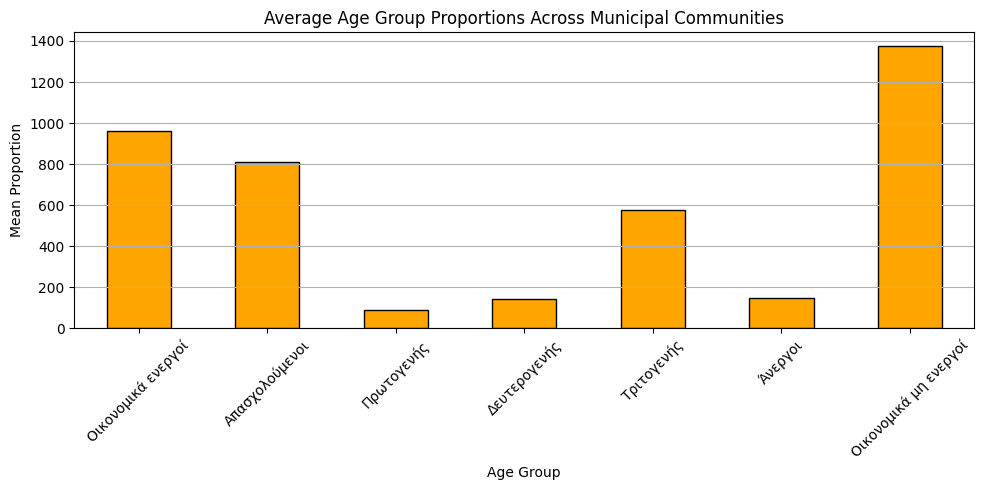

In [85]:
# plot the average hierarchical-economic-group percentage per all the municipal communities
plot_group_means(df, hierarchical_economic_columns, color='orange')

The plots over each feature that display its frequency would be ***misleading***, because their scale depends on the total population of their corresponding Municipal Community --> it would make more sense to work with ***percentages***, and this is why I added the next features.

## ***Demographic Features: Transform Groups to Smaller Groups***

Next, I will **combine some features that belong to a group*** (age, education, ...) in order to have fewer total features.

### ***Age Groups***

In [87]:
age_group_features = ['0-4_pct', '5-9_pct', '10-14_pct', '15-19_pct',
       '20-24_pct', '25-29_pct', '30-34_pct', '35-39_pct', '40-44_pct',
       '45-49_pct', '50-54_pct', '55-59_pct', '60-64_pct', '65-69_pct',
       '70-74_pct', '75+_pct'
]

In [88]:
df.shape

(76, 39)

In [89]:
# younger people
df["age_0_14_pct"] = df["0-4_pct"] + df["5-9_pct"] + df["10-14_pct"]

# working people
df["age_15_64_pct"] = (
    df["15-19_pct"] + df["20-24_pct"] + df["25-29_pct"] + df["30-34_pct"] +
    df["35-39_pct"] + df["40-44_pct"] + df["45-49_pct"] + df["50-54_pct"] +
    df["55-59_pct"] + df["60-64_pct"]
)

# elderly people
df["age_65_plus_pct"] = (
    df["65-69_pct"] + df["70-74_pct"] + df["75+_pct"]
)


In [90]:
# drop old columns
df.drop(columns=age_group_features, inplace=True)

### ***Education-Level Groups***

In [91]:
df.shape

(76, 26)

In [92]:
education_level_group_features = ['higher_education_pct',
       'post_secondary_non_uni_pct', 'high_school_pct', 'lower_secondary_pct',
       'primary_education_pct', 'no_formal_education_pct',
]

In [93]:
# low education people
df["low_education_pct"] = (
    df["no_formal_education_pct"] +
    df["primary_education_pct"] +
    df["lower_secondary_pct"]
)

# medium education people
df["medium_education_pct"] = (
    df["high_school_pct"] +
    df["post_secondary_non_uni_pct"]
)

# high education people
df["high_education_pct"] = df["higher_education_pct"]

In [94]:
# Now drop the old features
df.drop(columns=education_level_group_features, inplace=True)

In [95]:
df.shape

(76, 23)

### ***Marriage-Status Groups***

These are pretty straight-forward so I will keep them as they are

## ***Economic Features: Transform Hierarchical to Fractions***

First of all, since I have some ***compositional feature groups***, I will inspepct them to see if there is a case of ***multicolinearity***

### ***Add the Feature: 'unemployment_rate'***

In [96]:
df['unemployment_rate'] = df['Άνεργοι'] / df['Οικονομικά ενεργοί']

### ***Add the Feature: 'labor_force_participation_rate'***

In [97]:
df['labor_force_participation_rate'] = df['Οικονομικά ενεργοί'] / df['Σύνολο']

### ***Add the Features: 'primary/secondary/tertiary_sector_pct'***

In [98]:
df['primary_sector_pct'] = df['Πρωτογενής'] / df['Απασχολούμενοι']
df['secondary_sector_pct'] = df['Δευτερογενής'] / df['Απασχολούμενοι']
df['tertiary_sector_pct'] = df['Τριτογενής'] / df['Απασχολούμενοι']

### ***Round the Values***

In [99]:
# Find all columns that are percentage features
pct_cols = [col for col in df.columns if col.endswith('_pct') or col.endswith('_rate')]

# Round those columns to 4 decimal places
df[pct_cols] = df[pct_cols].round(4)

### ***Drop the old Hierarchical Features***

In [100]:
df.shape

(76, 28)

In [101]:
df.drop(columns=['Οικονομικά ενεργοί',
       'Απασχολούμενοι', 'Πρωτογενής', 'Δευτερογενής', 'Τριτογενής', 'Άνεργοι',
       'Οικονομικά μη ενεργοί'
], inplace=True)

In [102]:
df.shape

(76, 21)

## ***Feature: 'Area_km2'***

I added this through QGIS, and I saved it in the file 'municipal_community_areas.csv', so we just add it here:

In [103]:
area_df = pd.read_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\4. Exploratory Data Analysis\\Extracted CSV Files\\municipal_community_areas.csv", index_col=0)

In [104]:
print(area_df.shape)
area_df.head()

(76, 4)


,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Area_km2
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,,,,
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Δημοτική Κοινότητα Βόλου,26.790807
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Αγριάς,3.737347
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Δρακείας,21.683415
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Διμηνίου,37.323451
ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Σέσκλου,37.329725


In [105]:
# Merge with df_main
df = pd.merge(df, area_df, on=["ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ", "ΔΗΜΟΣ", "ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ", "ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ"], how="left")

## ***Save the Data***

In [106]:
df.drop(columns=['Σύνολο'], inplace=True)

In [107]:
print(df.shape)
df.head()

(76, 21)


,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΣ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ,ΔΗΜΟΤΙΚΗ ΚΟΙΝΟΤΗΤΑ,Population,Άγαμοι_pct,Έγγαμοι_pct,Χήροι_pct,Διαζευγμένοι_pct,age_0_14_pct,...,age_65_plus_pct,low_education_pct,medium_education_pct,high_education_pct,unemployment_rate,labor_force_participation_rate,primary_sector_pct,secondary_sector_pct,tertiary_sector_pct,Area_km2
0,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΒΟΛΟΥ,Δημοτική Κοινότητα Βόλου,85806,0.4032,0.4630,0.0809,0.0528,0.1300,...,0.2221,0.3634,0.3663,0.2704,0.1545,0.4188,0.0313,0.1666,0.8022,26.790807
1,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Αγριάς,4926,0.3577,0.5173,0.0796,0.0461,0.1407,...,0.2359,0.4670,0.3341,0.1987,0.1555,0.3955,0.0816,0.1864,0.7314,3.737347
2,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΓΡΙΑΣ,Δημοτική Κοινότητα Δρακείας,369,0.3496,0.4580,0.1382,0.0325,0.1274,...,0.2873,0.6667,0.2493,0.0840,0.1439,0.3767,0.4545,0.0826,0.4628,21.683415
3,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Διμηνίου,2101,0.3889,0.5007,0.0776,0.0343,0.1480,...,0.2080,0.5437,0.3163,0.1395,0.2211,0.4327,0.1161,0.2365,0.6459,37.323451
4,ΠΕΡΙΦΕΡΕΙΑΚΗ ΕΝΟΤΗΤΑ ΜΑΓΝΗΣΙΑΣ,ΔΗΜΟΣ ΒΟΛΟΥ,ΔΗΜΟΤΙΚΗ ΕΝΟΤΗΤΑ ΑΙΣΩΝΙΑΣ,Δημοτική Κοινότητα Σέσκλου,899,0.3960,0.5184,0.0645,0.0234,0.1769,...,0.2147,0.6009,0.2812,0.1179,0.1304,0.3838,0.1424,0.3609,0.4967,37.329725


In [476]:
df.to_csv("C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\3. Base Datasets\\2. Data - Municipal Communities\\4. Exploratory Data Analysis\\Extracted CSV Files\\ELSTAT-demographic-economic.csv")